## define functions

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse


########################################
# helpers: parquet loading
########################################

def _list_parquet_files(path):
    """
    Handle both:
    - a single .parquet file
    - a directory containing many parquet shards (*.parquet)

    Returns list of parquet file paths.
    """
    if os.path.isdir(path):
        files = glob.glob(os.path.join(path, "*.parquet"))
        if len(files) == 0:
            raise FileNotFoundError(f"Directory {path} contains no .parquet files")
        return sorted(files)
    elif os.path.isfile(path):
        return [path]
    else:
        raise FileNotFoundError(f"{path} is not a file or directory")


def _load_transcripts_polars(files, nucleus_only, allowed_categories):
    """
    Fast path: read transcripts with polars scan_parquet over one or many files.
    Returns pandas DataFrame with ['cell_id','feature_name'].
    """
    import polars as pl

    lazy_list = []
    for f in files:
        lf = pl.scan_parquet(f).select(
            "cell_id",
            "feature_name",
            "codeword_category",
            "overlaps_nucleus",
        )
        lazy_list.append(lf)

    lf_all = pl.concat(lazy_list)

    filt = (pl.col("codeword_category").is_in(list(allowed_categories)))
    if nucleus_only:
        filt = filt & (pl.col("overlaps_nucleus") == 1)

    lf_filt = (
        lf_all
        .filter(filt)
        .select(["cell_id", "feature_name"])
    )

    df = lf_filt.collect().to_pandas()
    df = df.dropna(subset=["cell_id", "feature_name"])
    return df


def _load_transcripts_pyarrow(files, nucleus_only, allowed_categories):
    """
    Fallback: use pyarrow to read + concat shards.
    Returns pandas DataFrame with ['cell_id','feature_name'].
    """
    import pyarrow.parquet as pq
    import pyarrow as pa

    cols = ["cell_id", "feature_name", "codeword_category", "overlaps_nucleus"]
    tables = []
    for f in files:
        tbl = pq.read_table(f, columns=cols)
        tables.append(tbl)

    big_tbl = pa.concat_tables(tables, promote=True)
    df = big_tbl.to_pandas()

    mask = df["codeword_category"].isin(list(allowed_categories))
    if nucleus_only:
        mask = mask & (df["overlaps_nucleus"] == 1)

    df = df.loc[mask, ["cell_id", "feature_name"]].copy()
    df = df.dropna(subset=["cell_id", "feature_name"])
    return df


def _load_transcripts_pandas(files, nucleus_only, allowed_categories):
    """
    Last-resort fallback: pandas.read_parquet on each file.
    Returns pandas DataFrame with ['cell_id','feature_name'].
    """
    dfs = []
    for f in files:
        tdf = pd.read_parquet(f)
        # filter
        good = tdf["codeword_category"].isin(list(allowed_categories))
        if nucleus_only and "overlaps_nucleus" in tdf.columns:
            good = good & (tdf["overlaps_nucleus"] == 1)
        tdf = tdf.loc[good, ["cell_id", "feature_name"]].copy()
        tdf = tdf.dropna(subset=["cell_id", "feature_name"])
        dfs.append(tdf)

    if len(dfs) == 0:
        return pd.DataFrame(columns=["cell_id","feature_name"])
    return pd.concat(dfs, axis=0, ignore_index=True)


def _read_transcripts_fast(transcripts_path, nucleus_only, allowed_categories):
    """
    Robust loader for transcripts.
    Tries Polars -> PyArrow -> Pandas.
    Returns pandas DF with ['cell_id','feature_name'].
    """
    files = _list_parquet_files(transcripts_path)

    last_err = None
    # try polars
    try:
        df = _load_transcripts_polars(files, nucleus_only, allowed_categories)
        if df.shape[0] > 0:
            return df
        print(f"[warn] polars returned 0 rows from {transcripts_path}, trying pyarrow...")
    except Exception as e:
        last_err = e
        print(f"[warn] polars failed on {transcripts_path}: {e}")

    # try pyarrow
    try:
        df = _load_transcripts_pyarrow(files, nucleus_only, allowed_categories)
        if df.shape[0] > 0:
            return df
        print(f"[warn] pyarrow returned 0 rows from {transcripts_path}, trying pandas...")
    except Exception as e:
        last_err = e
        print(f"[warn] pyarrow failed on {transcripts_path}: {e}")

    # fallback pandas
    df = _load_transcripts_pandas(files, nucleus_only, allowed_categories)
    if df.shape[0] == 0:
        raise RuntimeError(
            f"no transcripts passed filters in {transcripts_path}; last_err={last_err}"
        )
    return df


def _load_cells_any(cells_path, x_key, y_key, extra_obs_cols):
    """
    Load cells.parquet quickly.
    We'll try pyarrow w/ column subset first; fallback to pandas.
    Returns a pandas DF indexed by cell_id.
    """
    cols = ["cell_id", x_key, y_key, *extra_obs_cols]
    # dedupe but keep order
    cols = list(dict.fromkeys(cols))

    # try pyarrow
    try:
        import pyarrow.parquet as pq
        tbl = pq.read_table(cells_path, columns=cols)
        cells_df = tbl.to_pandas()
    except Exception as e:
        print(f"[warn] pyarrow cells loader failed: {e}")
        # pandas fallback
        full_df = pd.read_parquet(cells_path)
        # keep only cols that actually exist
        use_cols = [c for c in cols if c in full_df.columns]
        cells_df = full_df[use_cols].copy()

    if "cell_id" not in cells_df.columns:
        raise KeyError(f"'cell_id' not found in {cells_path}")

    cells_df = cells_df.set_index("cell_id")
    return cells_df


########################################
# main builders
########################################

def load_xenium_to_anndata(
    transcripts_path,
    cells_path,
    min_counts_per_cell=100,
    min_cells_per_gene=100,
    nucleus_only=True,
    allowed_categories=("predesigned_gene", "custom_gene"),
    x_key="x_centroid",
    y_key="y_centroid",
    extra_obs_cols=("nucleus_area",),
    layer_name="counts",
):
    """
    Build an AnnData from raw Xenium parquet exports for ONE sample.
    Uses fast loaders (polars/pyarrow) with graceful fallback.
    """

    # ---------------------------
    # 1. read / filter transcripts
    # ---------------------------
    df_tx = _read_transcripts_fast(
        transcripts_path,
        nucleus_only=nucleus_only,
        allowed_categories=allowed_categories,
    )

    if df_tx.empty:
        raise ValueError(f"No transcripts passed filters in {transcripts_path}")

    # ---------------------------
    # 2. count transcripts per (cell_id × gene)
    # ---------------------------
    counts = (
        df_tx.groupby(["cell_id", "feature_name"])
        .size()
        .reset_index(name="count")
    )

    count_matrix = (
        counts.pivot(index="cell_id", columns="feature_name", values="count")
        .fillna(0)
        .astype(int)
    )

    # sparse CSR
    X_sparse = sparse.csr_matrix(count_matrix.values)

    # ---------------------------
    # 3. create AnnData
    # ---------------------------
    adata = ad.AnnData(X=X_sparse)

    adata.obs_names = count_matrix.index.astype(str)
    adata.var_names = count_matrix.columns.astype(str)

    adata.obs["cell_id"] = adata.obs_names
    adata.var["gene"] = adata.var_names

    # ---------------------------
    # 4. attach spatial / morphology metadata
    # ---------------------------
    cells_df = _load_cells_any(cells_path, x_key, y_key, extra_obs_cols)

    for col in [x_key, y_key, *extra_obs_cols]:
        if col in cells_df.columns:
            adata.obs[col] = adata.obs_names.map(cells_df[col])
        else:
            adata.obs[col] = np.nan

    # spatial coords for squidpy/plotting
    if x_key in adata.obs.columns and y_key in adata.obs.columns:
        adata.obsm["spatial"] = adata.obs[[x_key, y_key]].to_numpy()

    # ---------------------------
    # 5. stash raw counts layer
    # ---------------------------
    adata.layers[layer_name] = adata.X.copy()

    # ---------------------------
    # 6. QC + basic filters
    # ---------------------------
    sc.pp.calculate_qc_metrics(
        adata,
        inplace=True,
        percent_top=None,
        log1p=False,
    )

    sc.pp.filter_cells(adata, min_counts=min_counts_per_cell)
    sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)

    return adata


def load_all_xenium_runs(
    base_dir,
    min_counts_per_cell=100,
    min_cells_per_gene=100,
    nucleus_only=True,
    allowed_categories=("predesigned_gene", "custom_gene"),
    x_key="x_centroid",
    y_key="y_centroid",
    extra_obs_cols=("nucleus_area",),
    layer_name="counts",
):
    """
    Walk `base_dir`, find each sample subfolder, build AnnData,
    and concatenate them.

    Returns
    -------
    adata_all : AnnData (concatenated union-of-genes, CSR sparse)
    adata_list : list[AnnData] (per sample)
    """

    adata_list = []

    for sample in os.listdir(base_dir):
        sample_path = os.path.join(base_dir, sample)
        if not os.path.isdir(sample_path):
            continue  # skip stray files

        transcripts_path = os.path.join(sample_path, "transcripts.parquet")
        cells_path = os.path.join(sample_path, "cells.parquet")

        # tolerate either file or dir for transcripts
        # cells is usually 1 parquet file
        if not (os.path.exists(transcripts_path) or os.path.isdir(transcripts_path)):
            continue
        if not os.path.exists(cells_path):
            continue

        print(f"→ loading {sample} ...")
        try:
            _adata_ = load_xenium_to_anndata(
                transcripts_path=transcripts_path,
                cells_path=cells_path,
                min_counts_per_cell=min_counts_per_cell,
                min_cells_per_gene=min_cells_per_gene,
                nucleus_only=nucleus_only,
                allowed_categories=allowed_categories,
                x_key=x_key,
                y_key=y_key,
                extra_obs_cols=extra_obs_cols,
                layer_name=layer_name,
            )

            # guess sample_id from folder name (your old split('__')[2])
            parts = sample.split("__")
            if len(parts) >= 3:
                sample_id = parts[2]
            else:
                sample_id = sample
            _adata_.obs["sample_id"] = sample_id

            adata_list.append(_adata_)

        except Exception as e:
            print(f"[warn] skipping {sample}: {e}")
            continue

    if len(adata_list) == 0:
        raise RuntimeError(f"No valid samples loaded from {base_dir}")

    # concat (outer join on vars; fill missing with 0)
    adata_all = ad.concat(
        adata_list,
        join="outer",
        label="sample_id",
        keys=[a.obs["sample_id"].unique()[0] for a in adata_list],
        fill_value=0,
    )

    # enforce sparse CSR after concat (scanpy may densify)
    if not sparse.issparse(adata_all.X):
        adata_all.X = sparse.csr_matrix(adata_all.X)

    return adata_all, adata_list
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

def plot_spatial_compact(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,                    # figure height (inches)
    legend_col_width=1.2,        # width (inches) reserved for legend
):
    sids = list(ad.obs[groupby].unique())
    n = len(sids)
    rows = int(np.ceil(n / cols))

    # compute figure width: panels + skinny legend column
    panel_w = height * cols * 0.6 / rows   # keeps a pleasing aspect
    fig_w = panel_w + legend_col_width
    fig = plt.figure(figsize=(fig_w, height), constrained_layout=False)

    # Grid: left (panels), right (legend)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # colors/categories (respect ad.uns if present)
    cats = ad.obs[color].astype("category").cat.categories
    if f"{color}_colors" in ad.uns:
        cols_list = ad.uns[f"{color}_colors"]
    else:
        base = sc.plotting.palettes.default_20
        cols_list = (base * int(np.ceil(len(cats)/len(base))))[:len(cats)]

    # panels
    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])
        ad_sub = ad[ad.obs[groupby] == sid].copy()

        sc.pl.spatial(
            ad_sub,
            color=color,
            spot_size=spot_size,
            show=False,
            ax=ax,
            legend_loc=None,
            frameon=False,     # no frame
            title=sid,         # short title; comment out to save more space
        )
        # remove axis labels Scanpy adds ("spatial1/2")
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # blank unused axes (if any)
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # legend in the skinny column
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor=cols_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cats)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    # squeeze outer margins
    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()


## create anndata

In [2]:
base_dir = "/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_LARRK]mtDSB_brain_Xenium_5k/20250917__105547__GoncaloLeslie_5kMouse_run4/"

adata_all, adata_list = load_all_xenium_runs(base_dir)

print(adata_all)
adata_all.obs["sample_id"].value_counts()

→ loading output-XETG00045__0060539__RB4282__20250917__105852 ...
[warn] polars failed on /Volumes/Castelo_Branco/NGSDATA/[spatialOmics_LARRK]mtDSB_brain_Xenium_5k/20250917__105547__GoncaloLeslie_5kMouse_run4/output-XETG00045__0060539__RB4282__20250917__105852/transcripts.parquet: expected at least 1 source

This error occurred with the following context stack:
	[1] 'parquet scan' failed
	[2] 'select' input failed to resolve
	[3] 'filter' input failed to resolve
	[4] 'select' input failed to resolve



/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_45542/284338734.py:135: FutureWarning: promote has been superseded by promote_options='default'.
  df = _load_transcripts_pyarrow(files, nucleus_only, allowed_categories)


→ loading output-XETG00045__0060539__RB4350__20250917__105852 ...
[warn] polars failed on /Volumes/Castelo_Branco/NGSDATA/[spatialOmics_LARRK]mtDSB_brain_Xenium_5k/20250917__105547__GoncaloLeslie_5kMouse_run4/output-XETG00045__0060539__RB4350__20250917__105852/transcripts.parquet: expected at least 1 source

This error occurred with the following context stack:
	[1] 'parquet scan' failed
	[2] 'select' input failed to resolve
	[3] 'filter' input failed to resolve
	[4] 'select' input failed to resolve



/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_45542/284338734.py:135: FutureWarning: promote has been superseded by promote_options='default'.
  df = _load_transcripts_pyarrow(files, nucleus_only, allowed_categories)


→ loading output-XETG00045__0060539__RB4401__20250917__105852 ...
[warn] polars failed on /Volumes/Castelo_Branco/NGSDATA/[spatialOmics_LARRK]mtDSB_brain_Xenium_5k/20250917__105547__GoncaloLeslie_5kMouse_run4/output-XETG00045__0060539__RB4401__20250917__105852/transcripts.parquet: expected at least 1 source

This error occurred with the following context stack:
	[1] 'parquet scan' failed
	[2] 'select' input failed to resolve
	[3] 'filter' input failed to resolve
	[4] 'select' input failed to resolve



...

→ loading output-XETG00045__0060541__RB4676__20250917__105852 ...
[warn] polars failed on /Volumes/Castelo_Branco/NGSDATA/[spatialOmics_LARRK]mtDSB_brain_Xenium_5k/20250917__105547__GoncaloLeslie_5kMouse_run4/output-XETG00045__0060541__RB4676__20250917__105852/transcripts.parquet: expected at least 1 source

This error occurred with the following context stack:
	[1] 'parquet scan' failed
	[2] 'select' input failed to resolve
	[3] 'filter' input failed to resolve
	[4] 'select' input failed to resolve



/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_45542/284338734.py:135: FutureWarning: promote has been superseded by promote_options='default'.
  df = _load_transcripts_pyarrow(files, nucleus_only, allowed_categories)


AnnData object with n_obs × n_vars = 878003 × 5097
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'nucleus_area', 'n_genes_by_counts', 'total_counts', 'n_counts', 'sample_id'
    obsm: 'spatial'
    layers: 'counts'


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


sample_id
RB4403    122279
RB4620     79390
RB4676     73965
RB4282     72181
RB4653     70374
RB4401     70174
RB4498     68417
RB4627     65859
RB4405     65402
RB4350     64883
RB4630     62789
RB4658     62290
Name: count, dtype: int64

## normalize and log transform

In [3]:
sc.pp.normalize_total(adata_all)
sc.pp.log1p(adata_all)

In [7]:
adata_all.write('../data/mtDSB-nuclei-raw.h5ad')

In [10]:
adata_all

AnnData object with n_obs × n_vars = 878003 × 5097
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'nucleus_area', 'n_genes_by_counts', 'total_counts', 'n_counts', 'sample_id'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

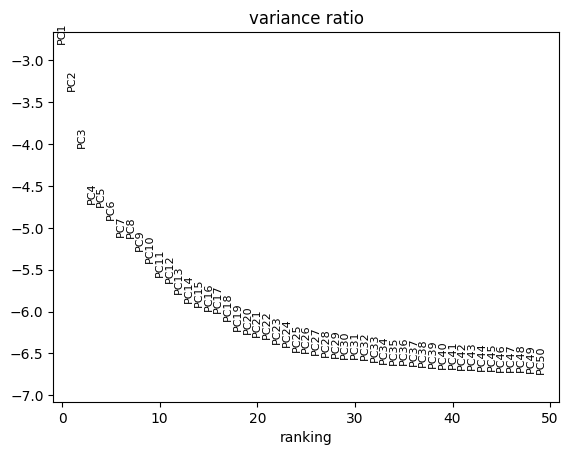

In [11]:
plt.rcdefaults()
sc.tl.pca(adata_all)
sc.pl.pca_variance_ratio(adata_all, n_pcs=50, log=True)
sc.pp.neighbors(adata_all, n_neighbors=15, n_pcs=30)

In [12]:
sc.tl.umap(adata_all, min_dist=0.1)

### clustering

Clustering at resolution 0.5...


IOStream.flush timed out


Done.


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


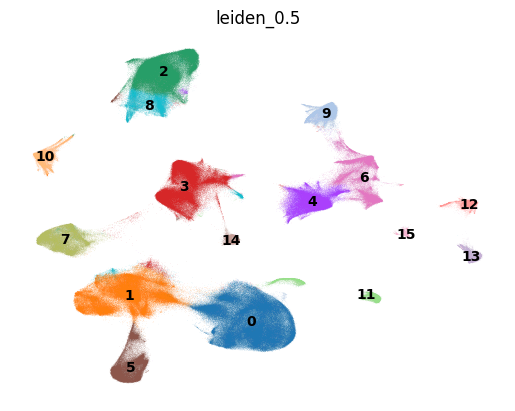

Clustering at resolution 1...


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


In [ ]:
resolutions = [0.5, 1,1.5, 2]

for resolution in resolutions:
    key = f'leiden_{resolution}'

    if key in adata_all.obs.columns:
        print(f"Skipping {resolution}: {key} already exists.")
    else:
        print(f"Clustering at resolution {resolution}...")
        sc.tl.leiden(adata_all, resolution=resolution, key_added=key)
        print("Done.")

    # plot UMAP
    sc.pl.umap(adata_all, color=key, legend_loc='on data', frameon=False)

In [ ]:
spatial = np.array(adata.obs[['x_centroid','y_centroid']])
adata.obsm['spatial'] = spatial

In [ ]:
adata

In [ ]:
# usage
plot_spatial_compact(
    adata,
    color="leiden_2",
    groupby="sample_id",
    spot_size=20,
    cols=6,
    height=8,
    legend_col_width=1.0,
)

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:401: P

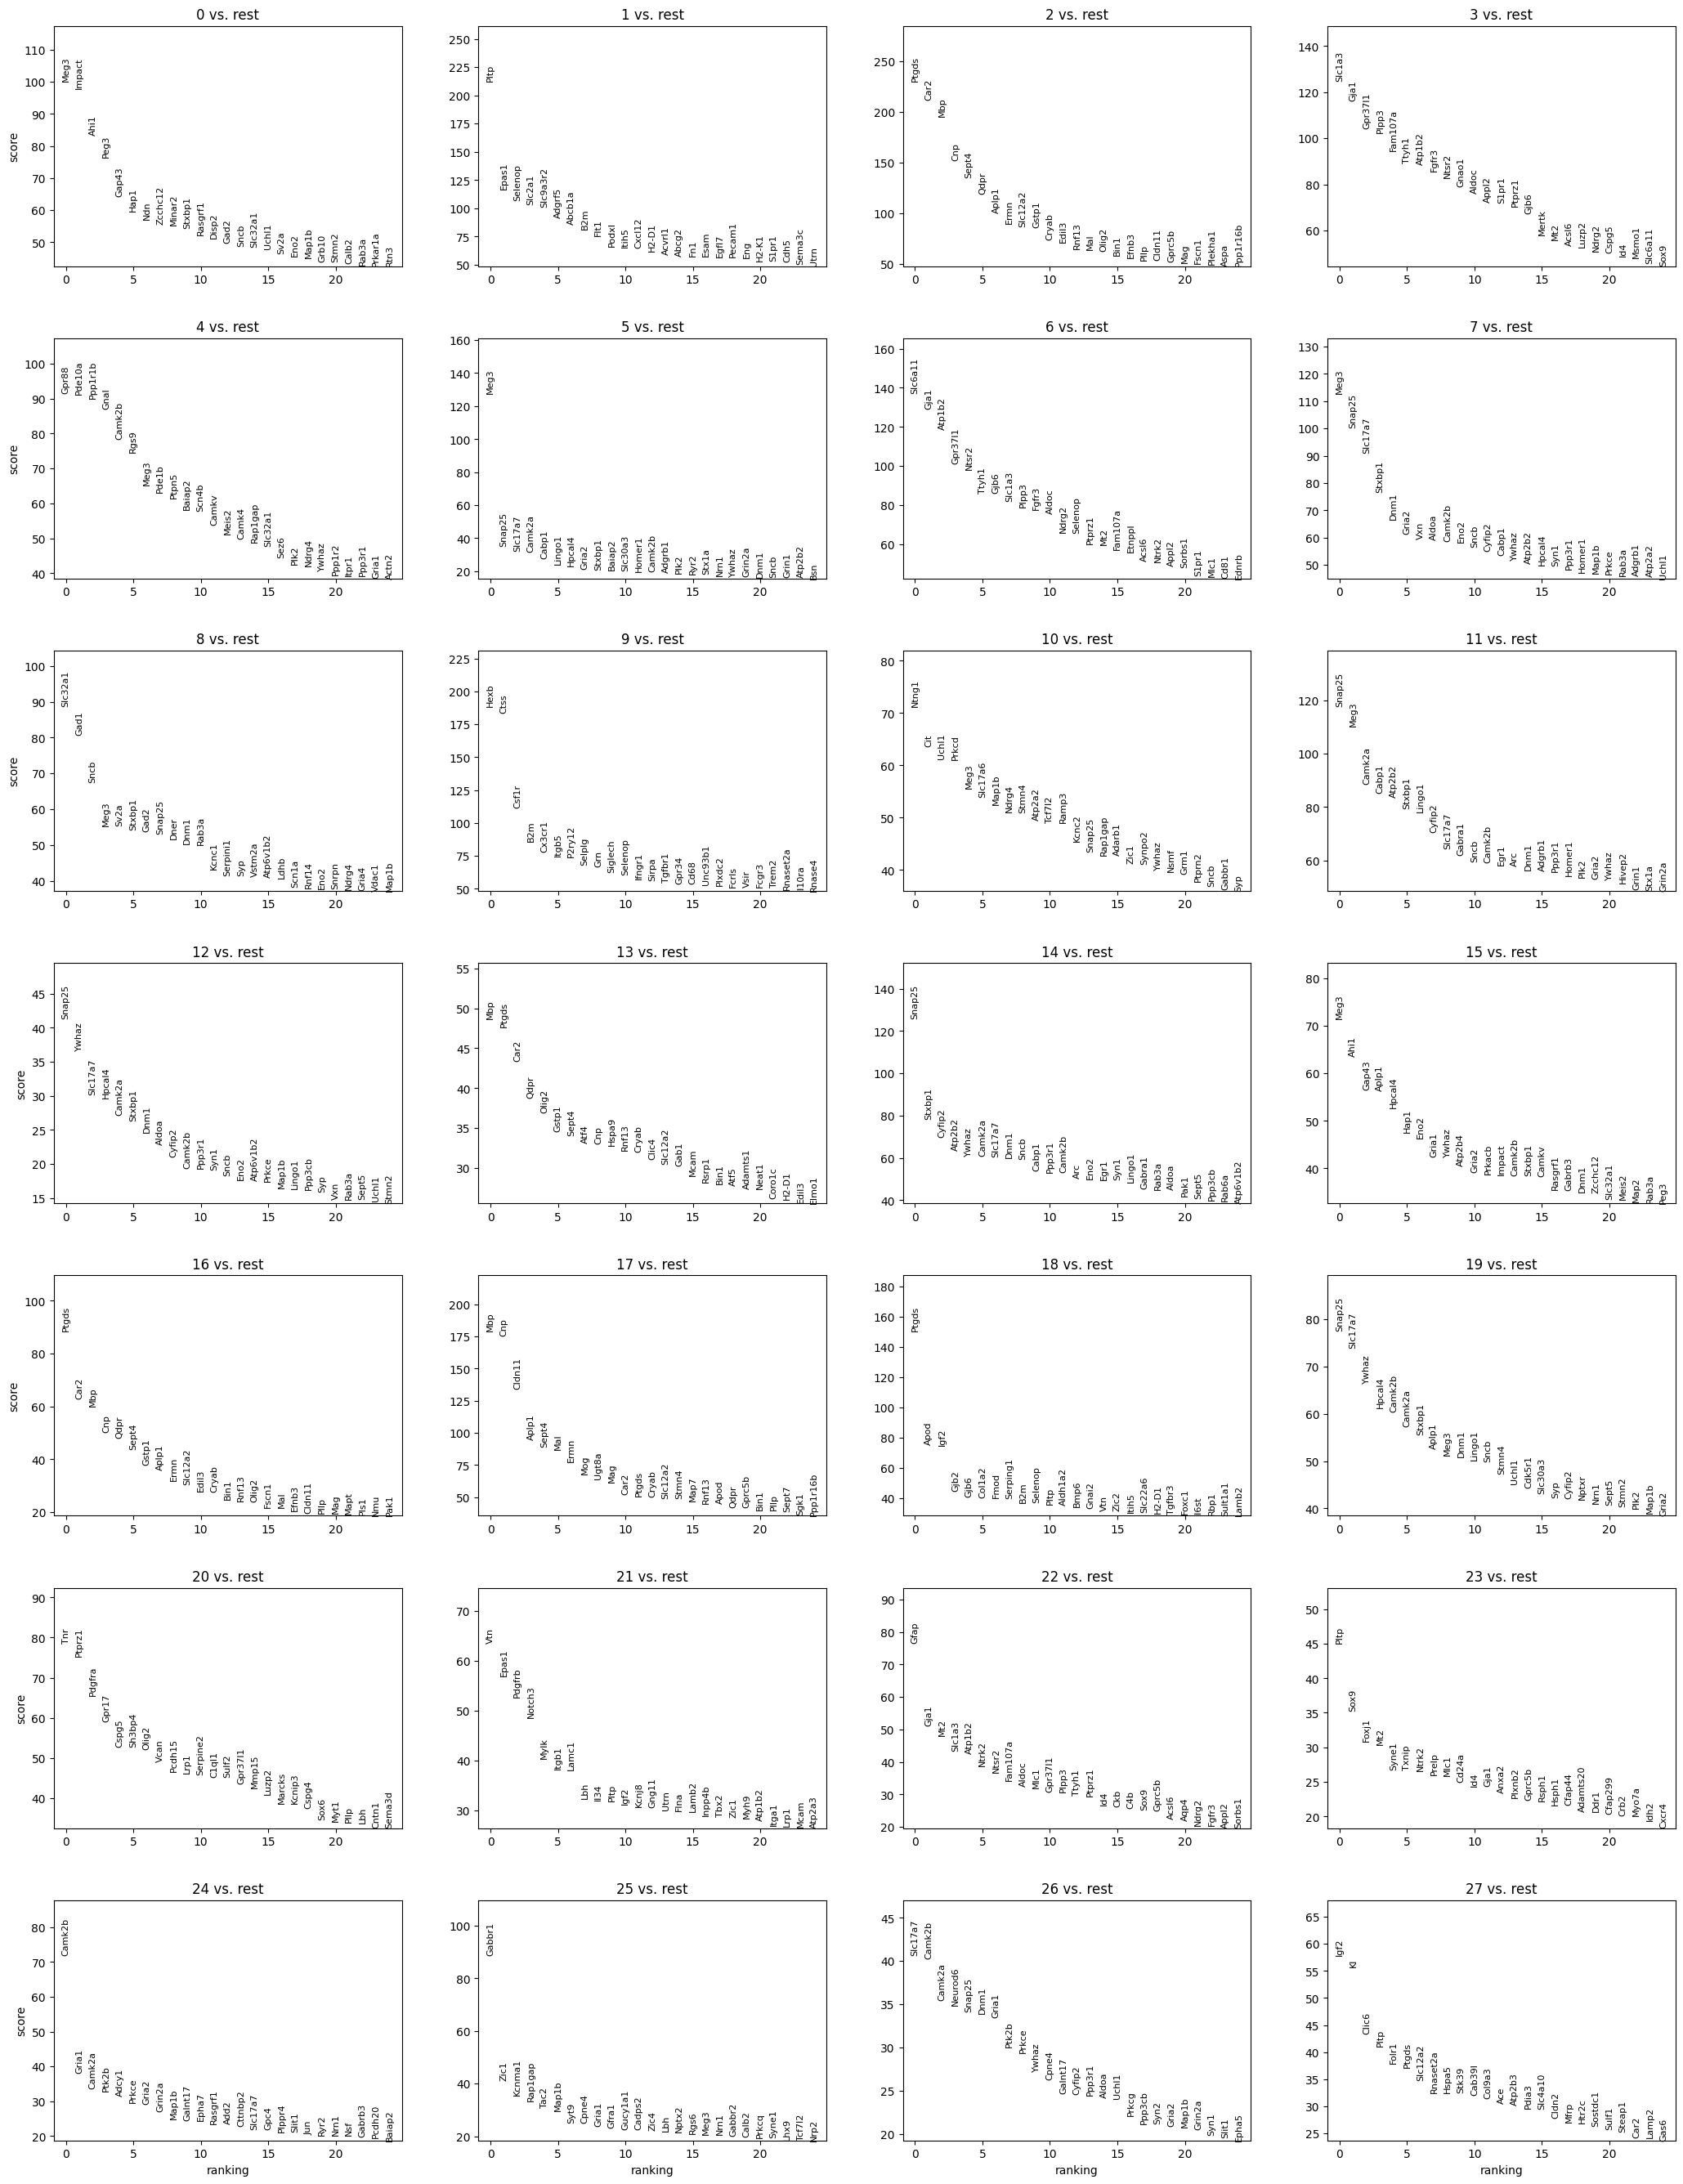

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Meg3,100.169907,2.323525,0.0,0.0
1,0,Impact,98.017288,2.396916,0.0,0.0
2,0,Ahi1,83.314850,2.509523,0.0,0.0
3,0,Peg3,76.549171,2.368623,0.0,0.0
4,0,Gap43,64.267242,2.000129,0.0,0.0


In [15]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata, groupby="leiden_2", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.head()

In [16]:
canonical_markers_mouse_brain = [
    "Snap25",     # Neurons (pan-neuronal synaptic marker)
    "Pdgfra",     # Oligodendrocyte precursor cells (OPCs)
    "Mbp",        # Mature oligodendrocytes (myelin marker)
    "Gfap",       # Astrocytes (intermediate filament protein)
    "P2ry12",     # Microglia (homeostatic marker)
    "Pecam1",     # Endothelial cells (vascular marker)
    "Pdgfrb",     # Pericytes (mural cell marker)
    "Col1a1",     # Fibroblasts / meningeal stromal cells
    "Foxj1",      # Ependymal cells (multiciliated)
    "Sox2"        # Neural stem cells / progenitors
]

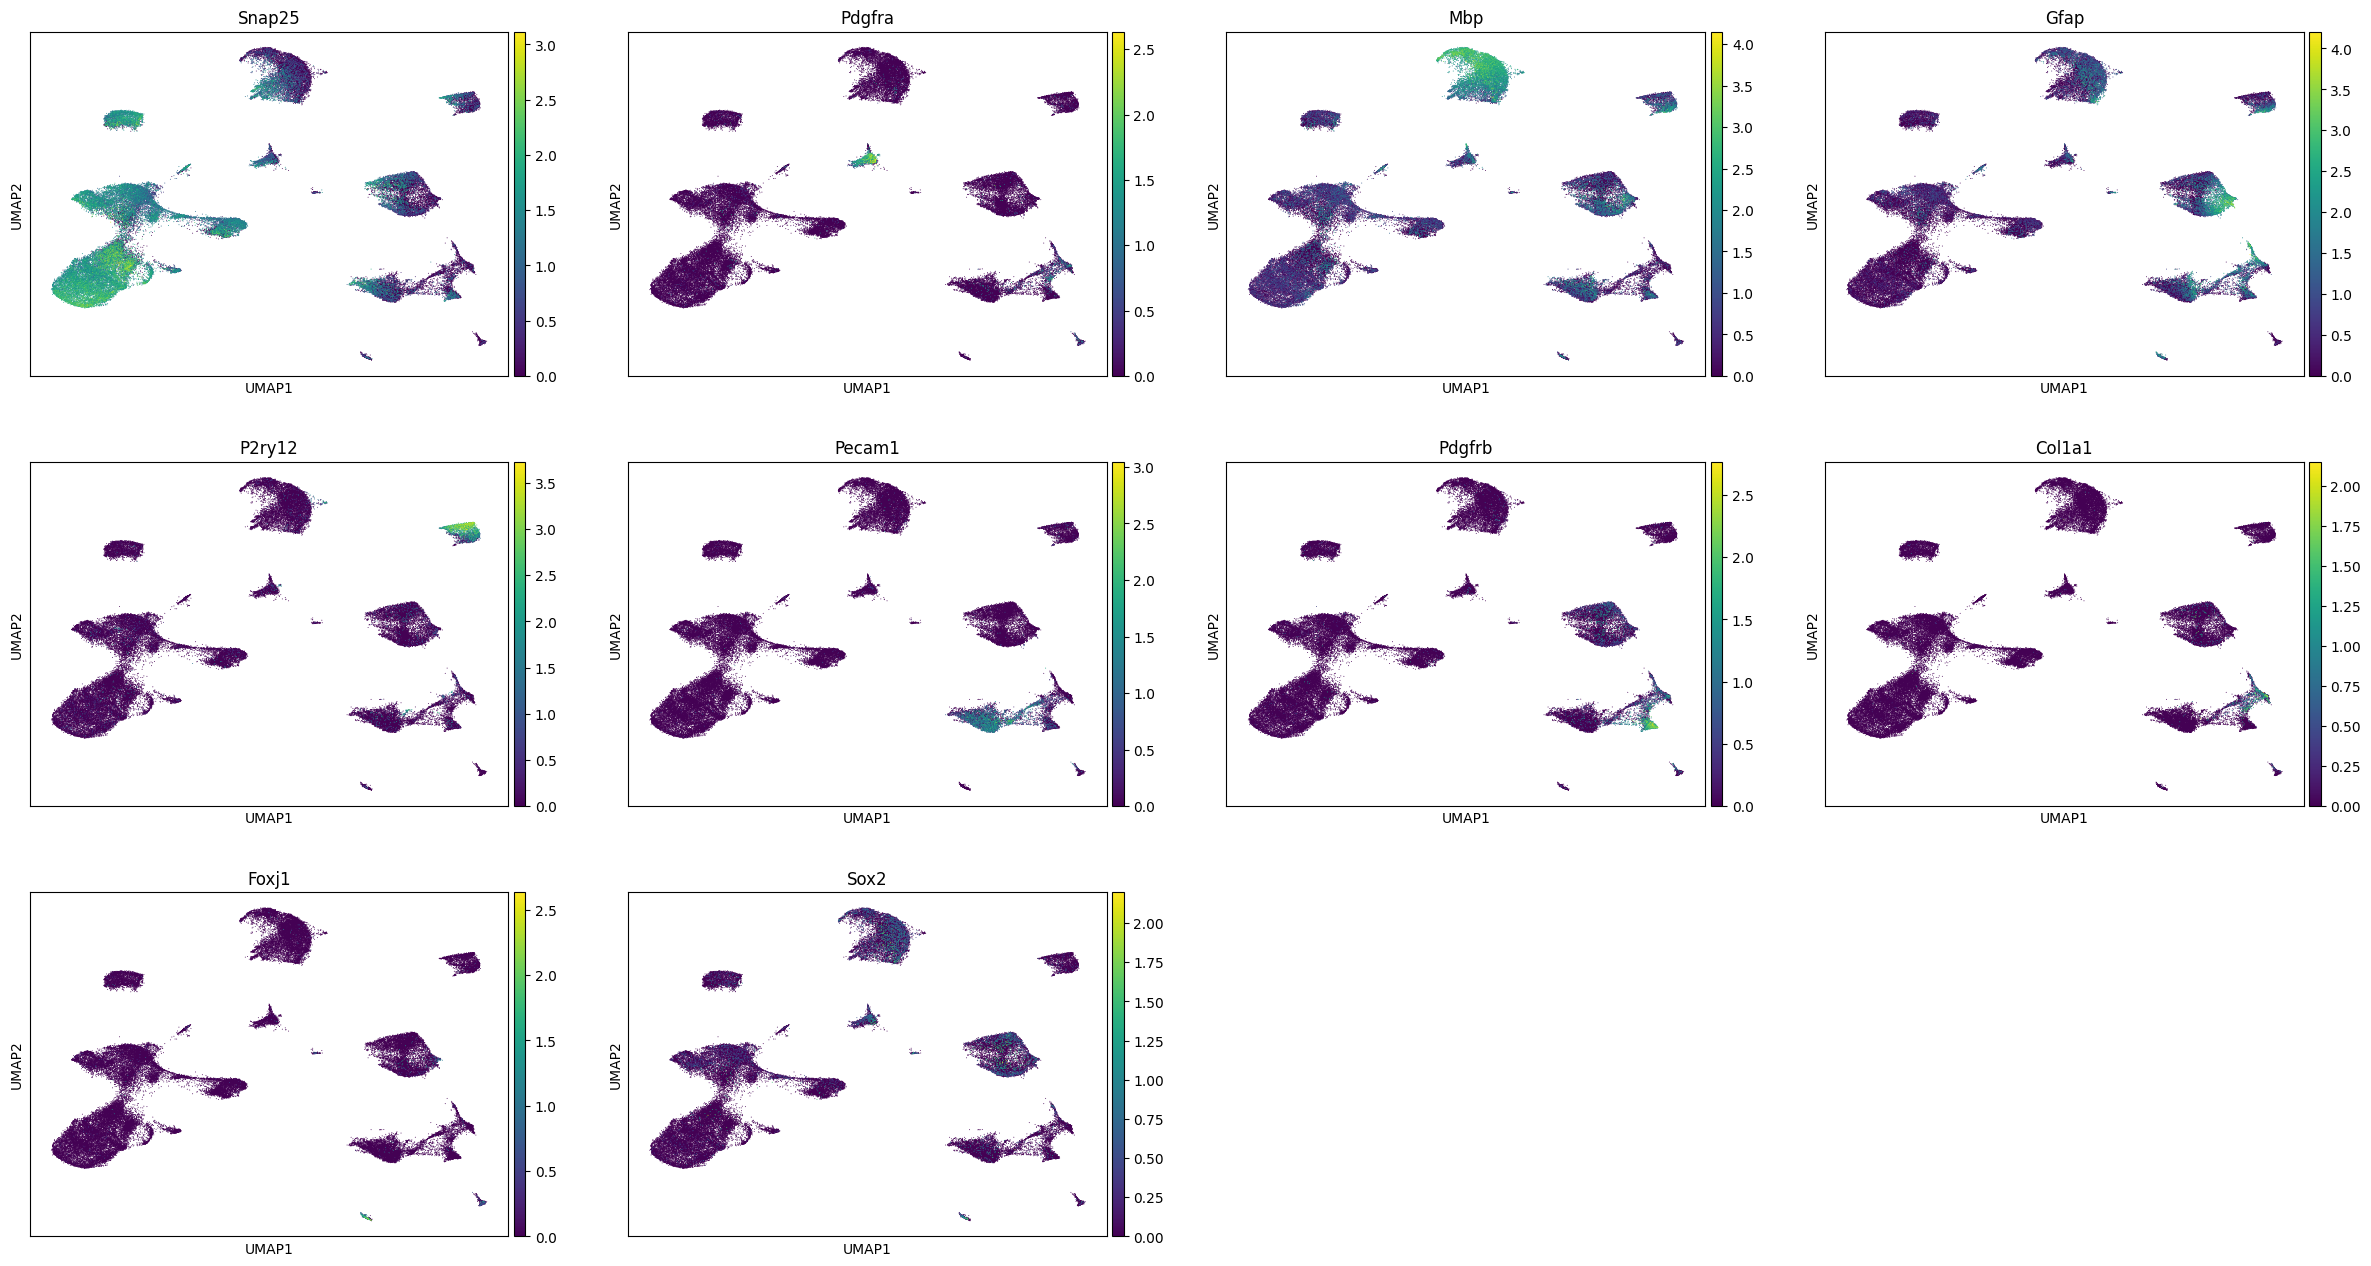

In [17]:
sc.pl.umap(adata, color = canonical_markers_mouse_brain)

In [18]:
marker_genes = pd.DataFrame({
    group: adata.uns['rank_genes_groups']['names'][group][:20]
    for group in adata.uns['rank_genes_groups']['names'].dtype.names
})


In [19]:
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

0
Meg3 Impact Ahi1 Peg3 Gap43 Hap1 Ndn Zcchc12 Minar2 Stxbp1 Rasgrf1 Disp2 Gad2 Sncb Slc32a1 Uchl1 Sv2a Eno2 Map1b Grb10
 
1
Pltp Epas1 Selenop Slc2a1 Slc9a3r2 Adgrf5 Abcb1a B2m Flt1 Podxl Itih5 Cxcl12 H2-D1 Acvrl1 Abcg2 Fn1 Esam Egfl7 Pecam1 Eng
 
2
Ptgds Car2 Mbp Cnp Sept4 Qdpr Aplp1 Ermn Slc12a2 Gstp1 Cryab Edil3 Rnf13 Mal Olig2 Bin1 Efnb3 Pllp Cldn11 Gprc5b
 
3
Slc1a3 Gja1 Gpr37l1 Plpp3 Fam107a Ttyh1 Atp1b2 Fgfr3 Ntsr2 Gnao1 Aldoc Appl2 S1pr1 Ptprz1 Gjb6 Mertk Mt2 Acsl6 Luzp2 Ndrg2
 
4
Gpr88 Pde10a Ppp1r1b Gnal Camk2b Rgs9 Meg3 Pde1b Ptpn5 Baiap2 Scn4b Camkv Meis2 Camk4 Rap1gap Slc32a1 Sez6 Plk2 Ndrg4 Ywhaz
 
5
Meg3 Snap25 Slc17a7 Camk2a Cabp1 Lingo1 Hpcal4 Gria2 Stxbp1 Baiap2 Slc30a3 Homer1 Camk2b Adgrb1 Plk2 Ryr2 Stx1a Nrn1 Ywhaz Grin2a
 
6
Slc6a11 Gja1 Atp1b2 Gpr37l1 Ntsr2 Ttyh1 Gjb6 Slc1a3 Plpp3 Fgfr3 Aldoc Ndrg2 Selenop Ptprz1 Mt2 Fam107a Etnppl Acsl6 Ntrk2 Appl2
 
7
Meg3 Snap25 Slc17a7 Stxbp1 Dnm1 Gria2 Vxn Aldoa Camk2b Eno2 Sncb Cyfip2 Cabp1 Ywhaz Atp2b2 Hpcal4 Syn1 Ppp3r1 H

In [20]:
from mllmcelltype import annotate_clusters, setup_logging

In [21]:
from dotenv import load_dotenv
import os

load_dotenv()  # will read .env into environment
api_key = os.getenv("../OPENAI_API_KEY")

In [22]:
marker_genes = marker_genes.T

In [23]:
marker_genes = marker_genes.reset_index().rename(columns={'index':'cluster'})

In [24]:
marker_genes = marker_genes.set_index("cluster").T.to_dict("list")

In [25]:
import os

# Annotate clusters with a single model
annotations = annotate_clusters(
    marker_genes=marker_genes,  # DataFrame or dictionary of marker genes
    species='mouse',               # Organism species
    provider='openai',            # LLM provider
    model='gpt-4o-mini',               # Specific model
    tissue='brain'                #Tissue context (optional but recommended)
)

# Print annotations
for cluster, annotation in annotations.items():
    print(f"Cluster {cluster}: {annotation}")

2025-10-29 12:25:34 - llmcelltype - INFO - Logging initialized. Log file: /Users/christoffer/.llmcelltype/logs/llmcelltype_20251029_122534.log
2025-10-29 12:25:34 - llmcelltype - INFO - Starting annotation with provider: openai
2025-10-29 12:25:34 - llmcelltype - INFO - Found 28 clusters
2025-10-29 12:25:34 - llmcelltype - INFO - Creating prompt for 28 clusters
2025-10-29 12:25:34 - llmcelltype - INFO - Generated prompt with 4881 characters
2025-10-29 12:25:34 - llmcelltype - INFO - Processing request with openai using model gpt-4o-mini
2025-10-29 12:25:34 - llmcelltype - INFO - Starting OpenAI API request with model: gpt-4o-mini
2025-10-29 12:25:34 - llmcelltype - INFO - Using model: gpt-4o-mini
2025-10-29 12:25:34 - llmcelltype - INFO - Processing 1 chunks of input
2025-10-29 12:25:34 - llmcelltype - INFO - Processing chunk 1 of 1
2025-10-29 12:25:34 - llmcelltype - INFO - Sending API request...
2025-10-29 12:25:42 - llmcelltype - INFO - Got response with 28 lines
2025-10-29 12:25:42

Cluster 0: Interneuron
Cluster 1: Endothelial cell
Cluster 2: Oligodendrocyte
Cluster 3: Astrocyte
Cluster 4: Striatal neuron
Cluster 5: Glutamatergic neuron
Cluster 6: Astrocyte
Cluster 7: Glutamatergic neuron
Cluster 8: GABAergic neuron
Cluster 9: Microglia
Cluster 10: Neuron
Cluster 11: Glutamatergic neuron
Cluster 12: Glutamatergic neuron
Cluster 13: Oligodendrocyte
Cluster 14: Glutamatergic neuron
Cluster 15: Striatal neuron
Cluster 16: Oligodendrocyte
Cluster 17: Oligodendrocyte
Cluster 18: Endothelial cell
Cluster 19: Glutamatergic neuron
Cluster 20: Oligodendrocyte
Cluster 21: Endothelial cell
Cluster 22: Astrocyte
Cluster 23: Ependymal cell
Cluster 24: Glutamatergic neuron
Cluster 25: Neuron
Cluster 26: Glutamatergic neuron
Cluster 27: Oligodendrocyte


In [56]:
cluster_annotations = {
    0: "Inhibitory neurons",
    1: "Endothelial cells",
    2: "Oligodendrocytes",
    3: "Astrocytes",
    4: "Striatal neurons",
    5: "Excitatory neurons",
    6: "Astrocytes",
    7: "Excitatory neurons",
    8: "Interneurons",
    9: "Microglia",
    10: "Projection neurons",
    11: "Excitatory neurons",
    12: "Excitatory neurons",
    13: "Oligodendrocytes (stress-related)",
    14: "Excitatory neurons",
    15: "Excitatory neurons",
    16: "Oligodendrocytes",
    17: "Oligodendrocytes",
    18: "Fibroblasts / meninges",
    19: "Excitatory neurons",
    20: "Oligodendrocyte precursor cells",
    21: "Pericytes",
    22: "Reactive astrocytes",
    23: "Ependymal cells",
    24: "Excitatory neurons",
    25: "Inhibitory neurons",
    26: "Excitatory neurons",
    27: "Choroid plexus",
}

In [57]:
adata.obs['cell_class'] = adata.obs['leiden_2'].astype(int).map(cluster_annotations)

... storing 'cell_class' as categorical
/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


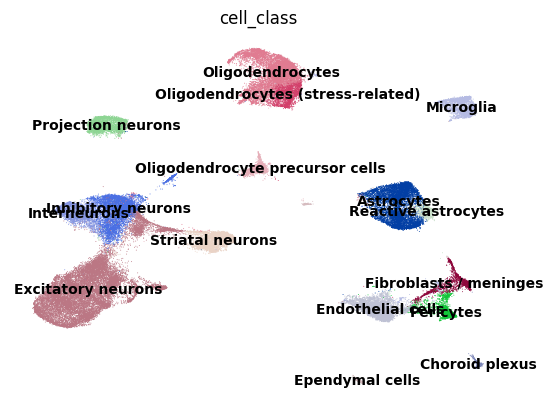

In [58]:
sc.pl.umap(adata, color='cell_class', legend_loc='on data', frameon=False)

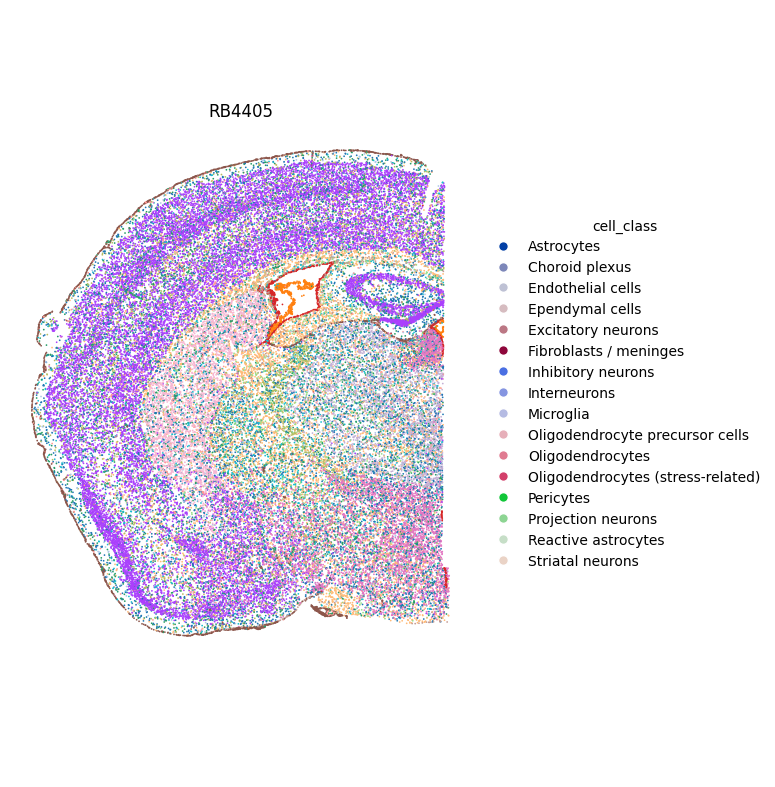

In [59]:
# usage
plot_spatial_compact(
    adata,
    color="cell_class",
    groupby="sample_id",
    spot_size=20,
    cols=1,
    height=8,
    legend_col_width=1.0,
)

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


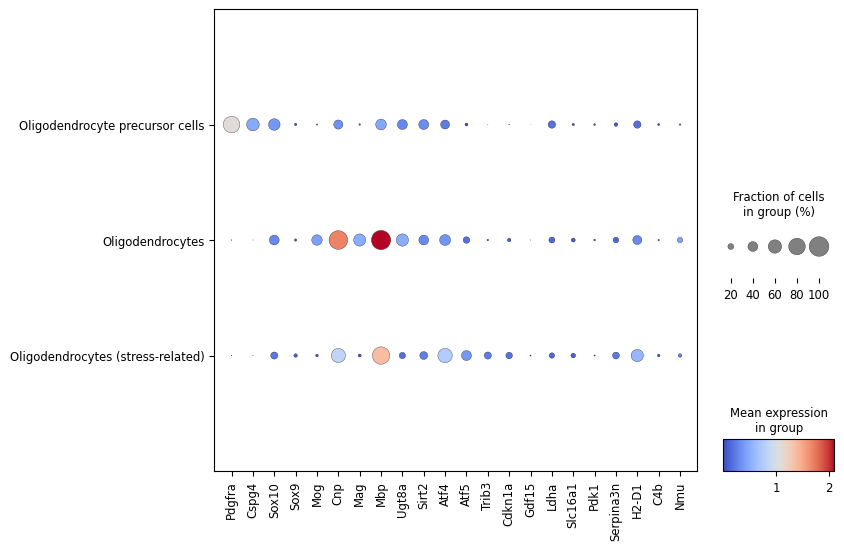

In [60]:
sc.pl.dotplot(
    adata[adata.obs.cell_class.str.contains('ligo', case=False)],
    var_names=[
        # OPC / progenitor
        'Pdgfra', 'Cspg4', 'Sox10', 'Sox9',
        # Newly formed / differentiating OLs
        'Mog', 'Cnp', 'Mag',
        # Mature myelinating
        'Mbp', 'Ugt8a', 'Sirt2',
        # Stress / ISR-related
        'Atf4', 'Atf5', 'Trib3', 'Cdkn1a', 'Gdf15',
        # Metabolic / glycolytic
        'Ldha', 'Slc16a1', 'Pdk1',
        # Reactive / immune-associated
        'Serpina3n', 'H2-D1', 'C4b',
        # Curious outlier to compare
        'Nmu'
    ],
    groupby="cell_class",
    color_map="coolwarm",
    #dendrogram=True,
    figsize=(8, 6)
)

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import scanpy as sc

def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
    show=True,               # toggle showing vs returning only
):
    """Fast, compact multi-sample spatial plot with shared legend.

    Returns:
        matplotlib.figure.Figure
    """
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()

    # ----- 1) Build shared palette -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = sc.pl.palettes.default_64 if hasattr(sc.pl.palettes, "default_64") else sc.pl.palettes.default_102
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    ad.uns[f"{color}_colors"] = col_list

    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Group indices -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])
        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # Blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig

In [62]:
adata_OL = adata[adata.obs.cell_class.str.contains('ligo')]

Plotting cell_class …


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_39143/1818311744.py:52: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  ad.uns[f"{color}_colors"] = col_list


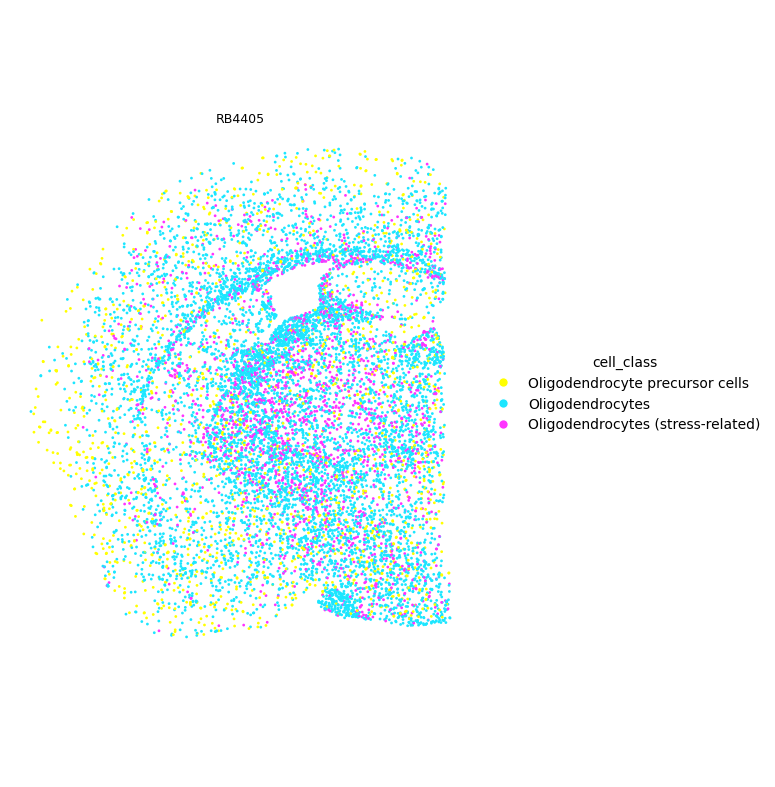

In [63]:
# --- make all axes dark background ---

import matplotlib as mpl
mpl.rcdefaults()
# --- output directory ---

# --- plot and save ---
for domain in ["cell_class"]:
    if domain in adata_OL.obs.columns:
        print(f"Plotting {domain} …")

        fig = plot_spatial_compact_fast(
            adata_OL,
            color=domain,
            groupby="sample_id",
            spot_size=4,
            cols=1,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # speedup for large data
            dpi=100,
            show=True          # <- don't display, just return
        )

       

    else:
        print(f"Skipping {domain} — not in adata.obs")